/var/folders/qj/vy5ztdf564jg38f9lktwgj6m0000gn/T/ipykernel_98293/3706476219.py:19: DtypeWarning: Columns (4,5,8,10,11,12,19,21,28,31,32,33,35,36,39,40,45,48,49,50,51,54,57,59,61,63,65,67,68,69,73,75,77,79,82,85,86,87,90,93,95,96,100,101,102,103,105,108,111,112,114,115,116,117,118,122,126,127,128,130,131,135,136,137,138,140,141,142,144,146,152,153,154,156,157,159,160,162,164,165,167,169,170,172,174,180,181,183,185,186,188,189,190,191,192,194,196,199,200,201,202,206,207,208,210,211,212,217,218,219,221,223,227,228,229,232,233,234,235,236,237,238,243,246,251,254,256,257,258,263,264,265,266,267,269,273,275,277,278,279,280,281,282,283,285,286,287,289,290,292,293,294,296,297,298,299,300,301,302,303,304,305,309,311,314,315,316,319,320,323,324,326,327,328,329,331,333,335,338,339,340,341,343,344,345,346,347,349,350,351,354,355,359,360,363,364,365,366,367,368,369,370,371,372,373,379,380,383,386,390,391,392,393,395,397,400,404,405,406,410,411,412,417,419,420,421,422,424,427,431,434,435,436,437,440

3898
3897
3897

[div_yield] 없어지는 칼럼 수: 9
['HD건설기계', 'HD현대건설기계', '네온테크', '덕양에너젠', '라온로보틱스', '라온테크', '스테이지원엔터', '엔에스이엔엠', '지아이에스']

[monthly_ret] 없어지는 칼럼 수: 4
['HD현대건설기계', '네온테크', '라온테크', '엔에스이엔엠']

[ivol] 없어지는 칼럼 수: 4
['HD현대건설기계', '네온테크', '라온테크', '엔에스이엔엠']

[dps_change_abs_12m] 없어지는 칼럼 수: 5
['HD건설기계', '덕양에너젠', '라온로보틱스', '스테이지원엔터', '지아이에스']

[adj_close_monthly] 없어지는 칼럼 수: 4
['HD현대건설기계', '네온테크', '라온테크', '엔에스이엔엠']

[제거된 칼럼 요약표]
  div_yield_drop monthly_ret_drop ivol_drop dps_change_abs_12m_drop  \
0         HD건설기계         HD현대건설기계  HD현대건설기계                  HD건설기계   
1       HD현대건설기계             네온테크      네온테크                   덕양에너젠   
2           네온테크             라온테크      라온테크                  라온로보틱스   
3          덕양에너젠           엔에스이엔엠    엔에스이엔엠                 스테이지원엔터   
4         라온로보틱스              NaN       NaN                   지아이에스   
5           라온테크              NaN       NaN                     NaN   
6        스테이지원엔터              NaN       NaN                     NaN   
7   

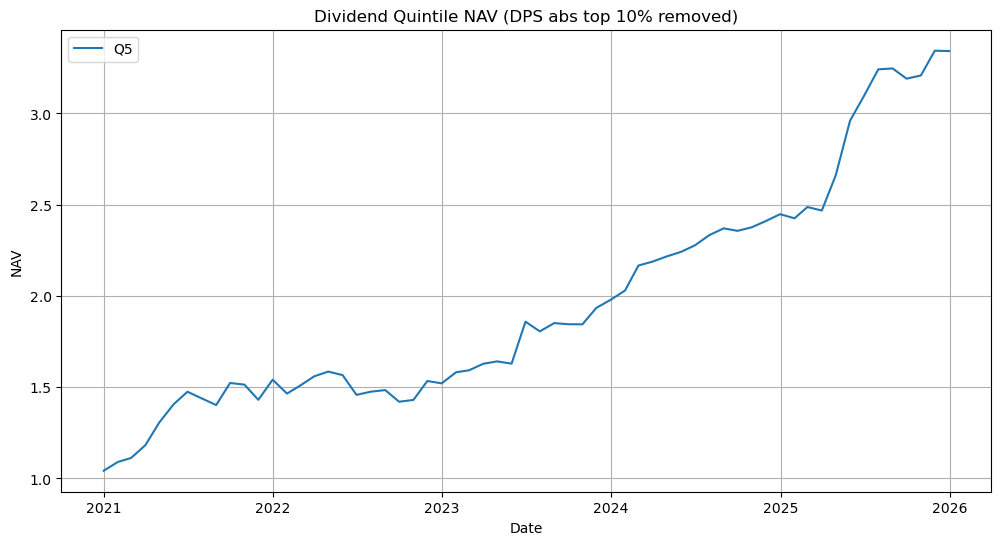

전략 vs KOSPI 성과 비교
비교 기간: 2020-12-31 ~ 2025-12-31
비교 개월 수: 61

                                    CAGR   Ann.Vol    Sharpe       MDD  \
High_Div_strategy_DPSabsFilter  0.267866  0.138603  1.795401 -0.104067   
KOSPI                           0.100386  0.208715  0.561517 -0.346163   

                                 HitRate  Avg.Monthly.Return  Months  
High_Div_strategy_DPSabsFilter  0.704918            0.020737    61.0  
KOSPI                           0.540984            0.009766    61.0  



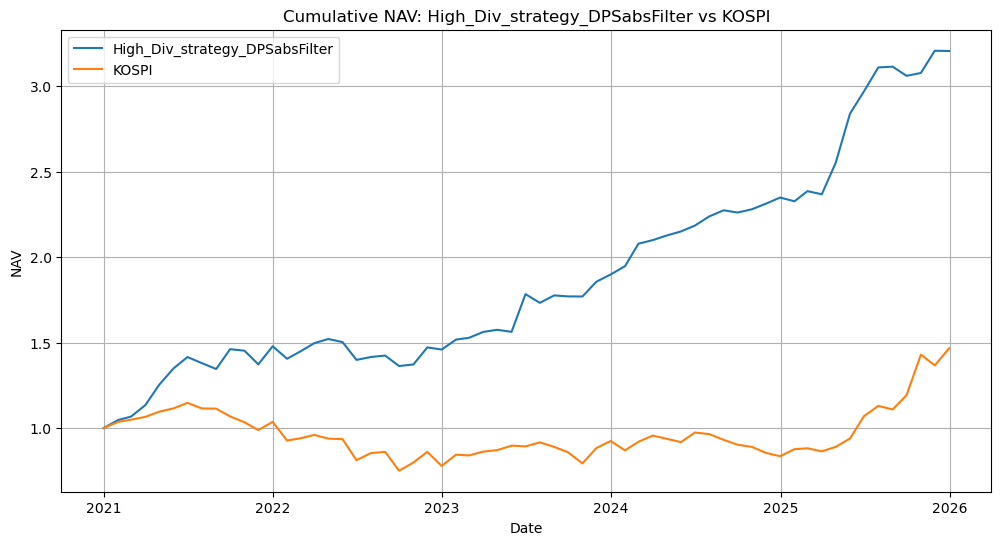

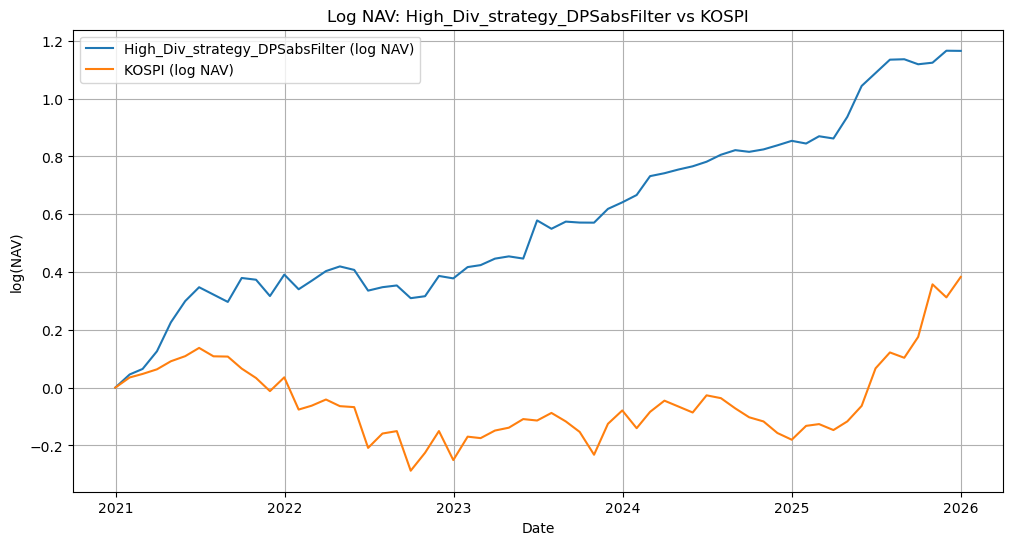

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     41.36
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           4.20e-16
Time:                        14:48:38   Log-Likelihood:                 134.48
No. Observations:                  61   AIC:                            -259.0
Df Residuals:                      56   BIC:                            -248.4
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0157      0.003      5.927      0.0

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# =========================================================
# 0. 데이터 불러오기
# =========================================================
adj_dps_raw = pd.read_csv(
    "/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/input/수정DPS.csv",
    index_col=0, parse_dates=True
)

adj_close_raw_index = pd.read_csv(
    "/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/input/수정종가.csv",
    index_col=0, parse_dates=True
)

is_kospi_raw = pd.read_csv(
    "/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/input/시장구분.csv",
    index_col=0, parse_dates=True
)

adj_close_raw_Div = pd.read_csv(
    "/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/input/배당반영수정주가.csv",  #배당반영수정주가
    index_col=0, parse_dates=True
)

# 계산해둔 ivol 데이터 사용
ivol_raw = pd.read_csv(
    "/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/input/ivol_df_60.csv",
    index_col=0, parse_dates=True
)

factors_raw = pd.read_csv(
    "/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/input/Factor.csv",
    index_col=0, parse_dates=True
)

# adj_close_raw 기준 칼럼 순서에 맞춰서 adj_close_raw_Div 정렬
adj_close_raw_Div_1 = adj_close_raw_Div.reindex(columns=adj_close_raw_index.columns)
adj_close_raw = adj_close_raw_Div_1


# =========================================================
# 1. 월말 데이터 생성
# =========================================================
adj_dps_shifted = (
    adj_dps_raw
    .resample("ME").last()
    .shift(15)
    .apply(pd.to_numeric, errors="coerce")
)

adj_close_monthly = (
    adj_close_raw
    .resample("ME").last()
    .apply(pd.to_numeric, errors="coerce")
)

is_kospi = (is_kospi_raw == "KSE").astype(int).resample("ME").last()

adj_close_index = (
    adj_close_raw_index
    .resample("ME").last()
    .apply(pd.to_numeric, errors="coerce")
)

# ivol도 월말 기준 정렬
ivol = (
    ivol_raw
    .resample("ME").last()
    .apply(pd.to_numeric, errors="coerce")
)

factors = (
    factors_raw
    .resample("ME").last()
    .apply(pd.to_numeric, errors="coerce")
)

KOSPI = factors[["KOSPI"]]

print(len(adj_dps_shifted.columns))
print(len(adj_close_monthly.columns))
print(len(ivol.columns))


# =========================================================
# 2. 배당수익률, 월수익률, DPS 변화율 절대값 계산
# =========================================================
div_yield = adj_dps_shifted / adj_close_monthly
monthly_ret = adj_close_monthly.pct_change(fill_method=None)

# DPS 12개월 변화율 절대값
dps_change_abs_12m = adj_dps_shifted.pct_change(periods=12, fill_method=None).abs()
dps_change_abs_12m = dps_change_abs_12m.replace([np.inf, -np.inf], np.nan)


# =========================================================
# 3. 공통 인덱스 / 공통 컬럼 정리
# =========================================================
common_index = (
    div_yield.index
    .intersection(monthly_ret.index)
    .intersection(is_kospi.index)
    .intersection(ivol.index)
    .intersection(dps_change_abs_12m.index)
)
common_index = common_index.sort_values()

common_cols = (
    div_yield.columns
    .intersection(monthly_ret.columns)
    .intersection(is_kospi.columns)
    .intersection(ivol.columns)
    .intersection(dps_change_abs_12m.columns)
)

# 각 데이터프레임에서 제거되는 칼럼 확인
dropped_cols = {
    "div_yield": div_yield.columns.difference(common_cols).tolist(),
    "monthly_ret": monthly_ret.columns.difference(common_cols).tolist(),
    "ivol": ivol.columns.difference(common_cols).tolist(),
    "dps_change_abs_12m": dps_change_abs_12m.columns.difference(common_cols).tolist(),
    "adj_close_monthly": adj_close_monthly.columns.difference(common_cols).tolist()
}

for name, cols in dropped_cols.items():
    print(f"\n[{name}] 없어지는 칼럼 수: {len(cols)}")
    print(cols)

div_yield = div_yield.loc[common_index, common_cols]
monthly_ret = monthly_ret.loc[common_index, common_cols]
adj_close_monthly = adj_close_monthly.loc[common_index, common_cols]
ivol = ivol.loc[common_index, common_cols]
dps_change_abs_12m = dps_change_abs_12m.loc[common_index, common_cols]
is_kospi = is_kospi.loc[common_index, common_cols]

dropped_cols_df = pd.DataFrame({
    "div_yield_drop": pd.Series(dropped_cols["div_yield"]),
    "monthly_ret_drop": pd.Series(dropped_cols["monthly_ret"]),
    "ivol_drop": pd.Series(dropped_cols["ivol"]),
    "dps_change_abs_12m_drop": pd.Series(dropped_cols["dps_change_abs_12m"]),
    "adj_close_monthly_drop": pd.Series(dropped_cols["adj_close_monthly"]),
})

print("\n[제거된 칼럼 요약표]")
print(dropped_cols_df.head(20))


# =========================================================
# 4. 백테스트 기간 설정
# =========================================================
BACKTEST_START = "2020-12-31"
BACKTEST_END   = "2025-12-31"

bt_start = pd.Timestamp(BACKTEST_START)
bt_end   = pd.Timestamp(BACKTEST_END)

# 성과가 기록될 월말 인덱스
bt_ret_index = common_index[(common_index >= bt_start) & (common_index <= bt_end)]

if len(bt_ret_index) == 0:
    raise ValueError("지정한 백테스트 구간에 해당하는 날짜가 없습니다.")


# =========================================================
# 5. 각 성과월(next_date)에 대응하는 직전 선택월(start_date) 생성
# =========================================================
valid_next_dates = []
selection_dates = []

for next_date in bt_ret_index:
    loc = common_index.get_loc(next_date)
    if loc == 0:
        continue
    start_date = common_index[loc - 1]
    valid_next_dates.append(next_date)
    selection_dates.append(start_date)

bt_ret_index = pd.Index(valid_next_dates)
selection_dates = pd.Index(selection_dates)

if len(bt_ret_index) == 0:
    raise ValueError("백테스트 시작 시점 이전에 최소 1개월의 선택용 데이터가 필요합니다.")


# =========================================================
# 6. 분위 배정 함수
# =========================================================
def assign_quintile(value, breakpoints):
    if pd.isna(value):
        return np.nan
    elif value <= 0:
        return 0
    elif value <= breakpoints.loc[0.2]:
        return 1
    elif value <= breakpoints.loc[0.4]:
        return 2
    elif value <= breakpoints.loc[0.6]:
        return 3
    elif value <= breakpoints.loc[0.8]:
        return 4
    else:
        return 5


# =========================================================
# 7. 월별 리밸런싱
#    순서:
#    KOSPI 유니버스
#    -> DPS 변화율 절대값 상위 10% 제거
#    -> 배당분위수 산정
#    -> 고배당 Q5 추출
#    -> Q5 내부에서 ivol 낮은 10종목 선택
# =========================================================
quintile_ret = pd.DataFrame(index=bt_ret_index, columns=[0, 1, 2, 3, 4, 5], dtype=float)

selected_universe_dict = {}
selected_quintile_dict = {}

portfolio_names_dict = {}
portfolio_names_meta = []

# 고배당(Q5) 통과 종목의 ivol 패널 저장용
ivol_q5_panel = pd.DataFrame(index=selection_dates, columns=common_cols, dtype=float)

for start_date, next_date in zip(selection_dates, bt_ret_index):

    # (1) 현재 시점 데이터
    dy_cs = div_yield.loc[start_date].astype(float)
    ivol_cs = ivol.loc[start_date].astype(float)
    dps_abs_cs = dps_change_abs_12m.loc[start_date].astype(float)
    kospi_cs = is_kospi.loc[start_date]

    # -------------------------------------------------
    # (2) 초기 유니버스:
    #     KOSPI 이면서
    #     dy, dps_abs 값이 존재하는 종목만 남기고
    #     DPS 변화율 절대값 상위 10% 제거
    # -------------------------------------------------
    base_mask = (
        dy_cs.notna() &
        dps_abs_cs.notna() &
        np.isfinite(dps_abs_cs) &
        (kospi_cs == 1)
    )

    base_dps_abs = dps_abs_cs[base_mask]

    if len(base_dps_abs) < 20:
        continue

    dps_abs_cutoff = base_dps_abs.quantile(0.9)

    filtered_mask = (
        base_mask &
        (dps_abs_cs <= dps_abs_cutoff)
    )

    # 이 필터를 통과한 종목만 이후 배당 분위수 산정에 사용
    dy_sort_base = dy_cs[filtered_mask]
    dy_positive = dy_sort_base[dy_sort_base > 0]

    if len(dy_positive) < 10:
        continue

    # (3) 필터 통과 유니버스에서 배당수익률 5분위 산정
    breakpoints = dy_positive.quantile([0.2, 0.4, 0.6, 0.8])
    quintile_series = dy_positive.apply(assign_quintile, args=(breakpoints,))

    # (4) 고배당 Q5만 추출
    q5_names = quintile_series[quintile_series == 5].index

    if len(q5_names) == 0:
        continue

    # (5) Q5 내부에서 ivol 필터
    ivol_q5 = ivol_cs.loc[q5_names].dropna()
    ivol_q5 = ivol_q5[np.isfinite(ivol_q5)]

    # ivol 패널 저장
    ivol_q5_panel.loc[start_date, ivol_q5.index] = ivol_q5.values

    # Q5 안에서 ivol 데이터가 10개 미만이면 그 달은 스킵
    if len(ivol_q5) < 10:
        continue

    # ivol 낮은 순으로 10개 선택
    final_q5_names = ivol_q5.nsmallest(10).index.tolist()

    # (6) 전체 종목 기준 분위수 시리즈 생성
    #     Q5는 ivol 필터 통과 종목만 남김
    full_quintile_series = pd.Series(index=common_cols, dtype=float)
    full_quintile_series.loc[:] = np.nan

    # 일단 배당 분위수 반영
    full_quintile_series.loc[quintile_series.index] = quintile_series

    # 원래 Q5였던 종목은 일단 0으로 내림
    full_quintile_series.loc[q5_names] = 0

    # ivol 필터 통과한 종목만 다시 5로 부여
    full_quintile_series.loc[final_q5_names] = 5

    # 가격은 있는데 분위수에 포함되지 않은 종목은 0 처리
    price_exists = adj_close_monthly.loc[start_date].notna()
    full_quintile_series = full_quintile_series.where(
        ~(full_quintile_series.isna() & price_exists),
        0
    )

    # 다음 달 수익률
    next_ret = monthly_ret.loc[next_date]

    # 저장
    selected_universe_dict[start_date] = list(dy_sort_base.index)
    selected_quintile_dict[start_date] = {}

    # 실제 보유/수익 실현 월(next_date) 기준으로 저장
    portfolio_names_dict[next_date] = list(final_q5_names)

    portfolio_names_meta.append({
        "selection_date": start_date,
        "holding_month": next_date,
        "n_stocks": len(final_q5_names),
        "stocks": list(final_q5_names),
        "dps_abs_cutoff": dps_abs_cutoff,
        "universe_after_dps_filter": len(dy_sort_base),
        "q5_count_before_ivol": len(q5_names)
    })





    # (7) 분위별 동일가중 수익률 계산
    for q in [0, 1, 2, 3, 4, 5]:
        selected_stocks = full_quintile_series[full_quintile_series == q].index
        selected_quintile_dict[start_date][q] = list(selected_stocks)

        if len(selected_stocks) == 0:
            quintile_ret.loc[next_date, q] = np.nan
        else:
            quintile_ret.loc[next_date, q] = next_ret[selected_stocks].mean()

quintile_ret = quintile_ret.dropna(how="all")

# 월별 전략 포트폴리오 구성종목 DataFrame 생성
portfolio_names_df = pd.DataFrame.from_dict(
    portfolio_names_dict,
    orient="index"
).sort_index()

portfolio_names_df.index.name = "holding_month"

if portfolio_names_df.shape[1] > 0:
    portfolio_names_df.columns = [f"stock_{i+1}" for i in range(portfolio_names_df.shape[1])]

print("=" * 80)
print("월별 전략 포트폴리오 구성종목 (wide format)")
print("=" * 80)
print(portfolio_names_df.head())
print()

portfolio_names_df.to_csv("portfolio_names_dps_abs_filtered.csv", encoding="utf-8-sig")

portfolio_names_meta_df = pd.DataFrame(portfolio_names_meta)
portfolio_names_meta_df.to_csv("portfolio_names_meta_dps_abs_filtered.csv", index=False, encoding="utf-8-sig")


# =========================================================
# 8. 누적 NAV 계산
# =========================================================
quintile_nav = (1 + quintile_ret).cumprod()

# 9. 고배당 포트폴리오(Q5)
high_div_ret = quintile_ret[5].dropna()
high_div_nav = (1 + high_div_ret).cumprod()


# =========================================================
# 10. 결과 출력
# =========================================================
print("=" * 80)
print("백테스트 결과 요약")
print("=" * 80)

if len(quintile_ret) == 0:
    print("결과가 없습니다. 필터가 너무 강하거나 백테스트 기간이 너무 짧을 수 있습니다.")
else:
    print(f"실제 성과 기간: {quintile_ret.index.min().date()} ~ {quintile_ret.index.max().date()}")
    print(f"성과 관측 개수: {len(quintile_ret)}개월")
    print()

    print("[분위별 월별 수익률 상위 5개]")
    print(quintile_ret.head())
    print()

    print("[분위별 월별 수익률 하위 5개]")
    print(quintile_ret.tail())
    print()

    print("[분위별 누적 NAV 하위 5개]")
    print(quintile_nav.tail())
    print()


# =========================================================
# 11. 성과지표 함수
# =========================================================
def calc_mdd(nav: pd.Series) -> float:
    nav = nav.dropna()
    if len(nav) == 0:
        return np.nan
    dd = nav / nav.cummax() - 1
    return dd.min()

def summarize_performance(ret: pd.Series, name: str = "") -> pd.Series:
    ret = ret.dropna()

    if len(ret) == 0:
        return pd.Series({
            "CAGR": np.nan,
            "Ann.Vol": np.nan,
            "Sharpe": np.nan,
            "MDD": np.nan,
            "HitRate": np.nan,
            "Avg.Monthly.Return": np.nan,
            "Months": 0
        }, name=name)

    nav = (1 + ret).cumprod()
    n = len(ret)

    cagr = nav.iloc[-1] ** (12 / n) - 1
    ann_vol = ret.std() * np.sqrt(12)
    sharpe = np.nan if ret.std() == 0 else ret.mean() / ret.std() * np.sqrt(12)
    mdd = calc_mdd(nav)
    hitrate = (ret > 0).mean()
    avg_monthly = ret.mean()

    return pd.Series({
        "CAGR": cagr,
        "Ann.Vol": ann_vol,
        "Sharpe": sharpe,
        "MDD": mdd,
        "HitRate": hitrate,
        "Avg.Monthly.Return": avg_monthly,
        "Months": n
    }, name=name)


# =========================================================
# 12. 분위별 / 전략별 성과표
# =========================================================
perf_list = []
perf_list.append(summarize_performance(high_div_ret, name="High Dividend (Q5, DPS abs top10% removed)"))

perf_table = pd.DataFrame(perf_list)

print("=" * 80)
print("성과표")
print("=" * 80)
print(perf_table)
print()


# =========================================================
# 13. 누적성과 그래프
# =========================================================
plt.figure(figsize=(12, 6))
for q in [5]:
    if q in quintile_nav.columns:
        plt.plot(quintile_nav.index, quintile_nav[q], label=f"Q{q}")
plt.title("Dividend Quintile NAV (DPS abs top 10% removed)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 14. 전략(high_div_ret) vs KOSPI 비교
# =========================================================
strategy_ret = high_div_ret.copy().dropna()
strategy_ret.index = pd.to_datetime(strategy_ret.index)
strategy_ret = strategy_ret.sort_index()
strategy_ret.name = "Strategy"

# KOSPI 수익률 만들기
if isinstance(KOSPI, pd.DataFrame):
    if KOSPI.shape[1] != 1:
        raise ValueError("KOSPI DataFrame의 컬럼이 1개가 아닙니다. 사용할 컬럼을 직접 지정해주세요.")
    kospi_price = KOSPI.iloc[:, 0].copy()
else:
    kospi_price = KOSPI.copy()

kospi_price.index = pd.to_datetime(kospi_price.index)
kospi_price = kospi_price.sort_index()
kospi_price = pd.to_numeric(kospi_price, errors="coerce")
kospi_price = kospi_price[~kospi_price.index.duplicated(keep="last")]

# 월말 가격 기준 월수익률
kospi_monthly_price = kospi_price.resample("ME").last()
kospi_ret = kospi_monthly_price.pct_change(fill_method=None).dropna()
kospi_ret.name = "KOSPI"

# 공통 기간 맞추기
compare_ret = pd.concat([strategy_ret, kospi_ret], axis=1).dropna()
compare_ret.columns = ["Strategy", "KOSPI"]

if len(compare_ret) == 0:
    raise ValueError("전략 수익률과 KOSPI 수익률의 겹치는 기간이 없습니다.")

compare_nav = (1 + compare_ret).cumprod()
compare_nav = compare_nav / compare_nav.iloc[0]
compare_log_nav = np.log(compare_nav)

perf_compare = pd.DataFrame([
    summarize_performance(compare_ret["Strategy"], "High_Div_strategy_DPSabsFilter"),
    summarize_performance(compare_ret["KOSPI"], "KOSPI")
])

print("=" * 90)
print("전략 vs KOSPI 성과 비교")
print("=" * 90)
print(f"비교 기간: {compare_ret.index.min().date()} ~ {compare_ret.index.max().date()}")
print(f"비교 개월 수: {len(compare_ret)}")
print()
print(perf_compare)
print()

plt.figure(figsize=(12, 6))
plt.plot(compare_nav.index, compare_nav["Strategy"], label="High_Div_strategy_DPSabsFilter")
plt.plot(compare_nav.index, compare_nav["KOSPI"], label="KOSPI")
plt.title("Cumulative NAV: High_Div_strategy_DPSabsFilter vs KOSPI")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(compare_log_nav.index, compare_log_nav["Strategy"], label="High_Div_strategy_DPSabsFilter (log NAV)")
plt.plot(compare_log_nav.index, compare_log_nav["KOSPI"], label="KOSPI (log NAV)")
plt.title("Log NAV: High_Div_strategy_DPSabsFilter vs KOSPI")
plt.xlabel("Date")
plt.ylabel("log(NAV)")
plt.grid(True)
plt.legend()
plt.show()


# =========================================================
# 15. 팩터 데이터 가공 함수
# =========================================================
def make_ff_factors(factors, freq="D", annual_rf=True):
    """
    factors: DataFrame with columns ['KOSPI','SMB','HML','MOM','RF']
    freq: 'D' (일간) 또는 'M' (월간)
    """
    df = factors.copy()

    # resampling
    if freq == "M":
        df = df.resample("ME").last()

    # 지수 -> 수익률 변환
    ret_cols = ["KOSPI", "SMB", "HML", "MOM"]
    df[ret_cols] = df[ret_cols].pct_change()

    # 무위험금리 변환 (연율 -> 일/월 수익률)
    df["RF"] = df["RF"] / 100

    if freq == "D":
        trading_days = 252
        df["RF"] = (1 + df["RF"]) ** (1 / trading_days) - 1
    elif freq == "M":
        df["RF"] = (1 + df["RF"]) ** (1 / 12) - 1

    df = df[["KOSPI", "SMB", "HML", "MOM", "RF"]].dropna()
    return df


# =========================================================
# 16. 월간 팩터 생성
# =========================================================
ff_monthly = make_ff_factors(factors, freq="M")


# =========================================================
# 17. 팩터 회귀
# =========================================================
portfolio_ret = high_div_ret.copy()
portfolio_ret.name = "Portfolio"

df = pd.concat([portfolio_ret, ff_monthly], axis=1, join="inner").dropna()

# 종속변수: 포트폴리오 초과수익률
y = df[portfolio_ret.name] - df["RF"]

# 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df["KOSPI"] - df["RF"],
    "SMB": df["SMB"],
    "HML": df["HML"],
    "MOM": df["MOM"]
}, index=df.index)

X = sm.add_constant(X, has_constant="add")

# OLS 회귀 (Newey-West 표준오차)
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(model.summary())

New Strategy vs Old Strategy
비교 기간: 2020-12-31 ~ 2025-12-31
비교 개월 수: 61

              Total Return      CAGR  Ann.Return   Ann.Vol    Sharpe  \
New Strategy      2.341613  0.267866    0.248848  0.138603  1.795401   
Old Strategy      2.341613  0.267866    0.248848  0.138603  1.795401   

                   MDD   HitRate  Months  
New Strategy -0.104067  0.704918    61.0  
Old Strategy -0.104067  0.704918    61.0  

             Total Return    CAGR Ann.Return Ann.Vol  Sharpe      MDD HitRate  \
New Strategy      234.16%  26.79%     24.88%  13.86%  1.7954  -10.41%  70.49%   
Old Strategy      234.16%  26.79%     24.88%  13.86%  1.7954  -10.41%  70.49%   

              Months  
New Strategy    61.0  
Old Strategy    61.0  


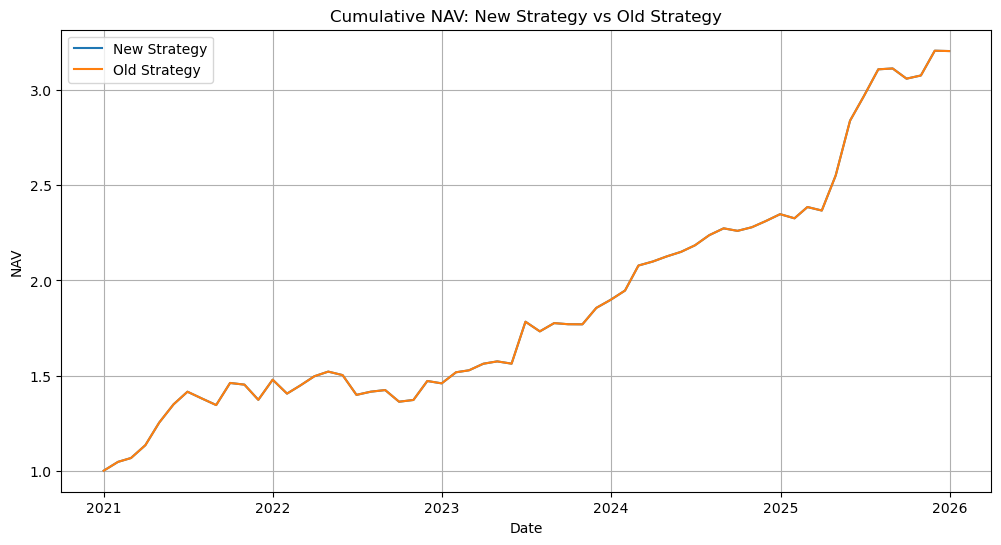

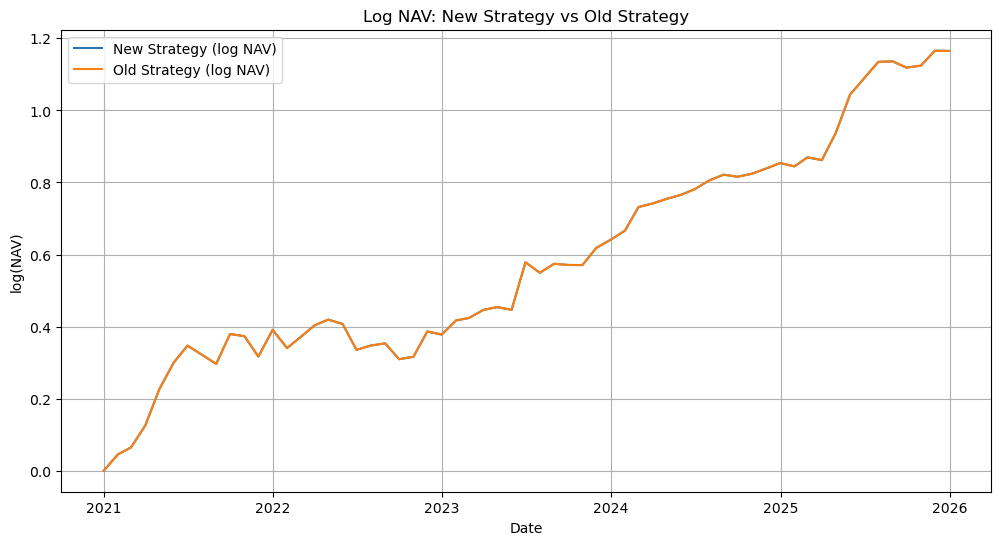

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. old strategy NAV 불러오기
# =========================================================
old_nav_df = pd.read_csv("old_strategy_nav.csv")
old_nav_df["Date"] = pd.to_datetime(old_nav_df["Date"])
old_nav_df = old_nav_df.sort_values("Date").set_index("Date")

old_nav = old_nav_df["NAV"].copy()
old_nav.name = "Old Strategy"

# old strategy 수익률 복원
old_ret = old_nav.pct_change(fill_method=None).dropna()
old_ret.name = "Old Strategy"

# =========================================================
# 2. 현재 전략 정리
# =========================================================
new_ret = high_div_ret.copy().dropna()
new_ret.name = "New Strategy"

new_nav = high_div_nav.copy().dropna()
new_nav.name = "New Strategy"

# =========================================================
# 3. 공통 기간 맞추기
# =========================================================
compare_ret = pd.concat([new_ret, old_ret], axis=1).dropna()
compare_ret.columns = ["New Strategy", "Old Strategy"]

compare_nav = (1 + compare_ret).cumprod()
compare_nav = compare_nav / compare_nav.iloc[0]

# =========================================================
# 4. 성과지표 함수
# =========================================================
def calc_mdd(nav):
    dd = nav / nav.cummax() - 1
    return dd.min()

def summarize_performance(ret, name=""):
    ret = ret.dropna()
    nav = (1 + ret).cumprod()
    n = len(ret)

    cagr = nav.iloc[-1] ** (12 / n) - 1
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * np.sqrt(12)
    sharpe = np.nan if ret.std() == 0 else ret.mean() / ret.std() * np.sqrt(12)
    mdd = calc_mdd(nav)
    hitrate = (ret > 0).mean()

    return pd.Series({
        "Total Return": nav.iloc[-1] - 1,
        "CAGR": cagr,
        "Ann.Return": ann_ret,
        "Ann.Vol": ann_vol,
        "Sharpe": sharpe,
        "MDD": mdd,
        "HitRate": hitrate,
        "Months": n
    }, name=name)

# =========================================================
# 5. 성과표
# =========================================================
perf_compare = pd.DataFrame([
    summarize_performance(compare_ret["New Strategy"], "New Strategy"),
    summarize_performance(compare_ret["Old Strategy"], "Old Strategy")
])

print("=" * 90)
print("New Strategy vs Old Strategy")
print("=" * 90)
print(f"비교 기간: {compare_ret.index.min().date()} ~ {compare_ret.index.max().date()}")
print(f"비교 개월 수: {len(compare_ret)}")
print()
print(perf_compare)
print()

# 보기 좋게 출력
perf_compare_fmt = perf_compare.copy()
for col in ["Total Return", "CAGR", "Ann.Return", "Ann.Vol", "MDD", "HitRate"]:
    perf_compare_fmt[col] = perf_compare_fmt[col].map(lambda x: f"{x:.2%}")
perf_compare_fmt["Sharpe"] = perf_compare_fmt["Sharpe"].map(lambda x: f"{x:.4f}")
print(perf_compare_fmt)

# =========================================================
# 6. NAV 그래프
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(compare_nav.index, compare_nav["New Strategy"], label="New Strategy")
plt.plot(compare_nav.index, compare_nav["Old Strategy"], label="Old Strategy")
plt.title("Cumulative NAV: New Strategy vs Old Strategy")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.legend()
plt.show()

# 로그 NAV 그래프
plt.figure(figsize=(12, 6))
plt.plot(compare_nav.index, np.log(compare_nav["New Strategy"]), label="New Strategy (log NAV)")
plt.plot(compare_nav.index, np.log(compare_nav["Old Strategy"]), label="Old Strategy (log NAV)")
plt.title("Log NAV: New Strategy vs Old Strategy")
plt.xlabel("Date")
plt.ylabel("log(NAV)")
plt.grid(True)
plt.legend()
plt.show()